# AmbaMPS - YOLOX using SageMaker APIs

## Introduction

The Jupyter notebook that explains how to use Ambarella's Model Preperation Service (AmbaMPS) using AWS SageMaker Python APIs for YOLOX model.
Users can subscribe to the algorithm from the product listing page: # TODO

The algorithm trains a YOLOX small variant model on user's dataset and generates optimized binaries for Ambarella platform. There are 2 components to SageMaker: 

**1. Training the model:**  
Users are provided with options for hyper-parameters allowing them to train the model for their dataset. The output of training is Ambarella's proprietary AmbaPB checkpoint best suited for running optimized inference on Ambarella's CV chips along with Cavalry binary that run's on the device with Ambarella's SDK.

**2. Running Inference:**  
Users can run batch transforms or real time predictions on the output of training. The inference runs forward pass on the AmbaPB on the host and outputs results in application/json format which contains the boxes, scores and labels output.

The notebook shows example using Aquarium dataset with 8 classes.

## Prerequisite


**1. Configure AWS**  
Please install AWS CLI and run `aws configure` to configure your aws account.

<br>

**2. Install SageMaker Python library**  
Please install `sagemaker` python library [SageMaker Python API](https://github.com/aws/sagemaker-python-sdk)

## Preparing the data

The algorithm is based off of YOLOX [GitHub](https://github.com/Megvii-BaseDetection/YOLOX.git). Please refer to the tutorial page to learn about the format for data preparation. [Custom Dataset Preparation](https://github.com/Megvii-BaseDetection/YOLOX/blob/main/docs/train_custom_data.md)

The algorithm currently supports only COCO format dataset with COCO evaluators which is part of the repo. The dataset used in the notebook is from Roboflow [Aquarium](https://universe.roboflow.com/roboflow-100/aquarium-qlnqy/dataset/1). Please download the dataset in the **COCO JSON** format. 


Typically, the dataset downloaded from Roboflow in the COCO format will have the following folder structure.

```
dataset/
├── README.dataset.txt
├── README.roboflow.txt
├── train
│   ├──  _annotations.coco.json
│   ├──  imgxxx0.jpg
│   ├──  ...
│   ├──  imgxxxN.jpg
├── valid
│   ├──  _annotations.coco.json
│   ├──  imgxxx0.jpg
│   ├──  ...
│   ├──  imgxxxN.jpg
```

Please prepare the folder structure in the following format:

1. Create 3 folders:
     
    a. train2017
     
    b. val2017
  
    c. annotations  


3. Copy the _annotations.coco.json in both the train and valid folders into annotations folder and name them as instances_train2017.json and instances_val2017.json respectively.

4. Copy the images from train and valid into train2017 and val2017 respectively. 

Here is an example of the folder structure.

```
dataset/
├── train2017
│   ├──  imgxxx0.jpg
│   ├──  ...
│   ├──  imgxxxN.jpg
├── val2017
│   ├──  imgxxx0.jpg
│   ├──  ...
│   ├──  imgxxxN.jpg
├── annotations
│   ├──  instances_train2017.json
│   ├──  instances_val2017.json
```


### Setting the class names 
Prepare the class names list by inspecting the annotations JSON file under the key `category`

In [1]:
class_names = ["aquarium", "fish", "jellyfish", "penguin", "puffin", "shark", "starfish", "stingray"]

## Run Training

The end-end workflow with training and inference using Python APIs requires the following:  

1. Subscription to Ambarella's algorithm 

2. SageMaker python package installed.  

3. Hyperparameters as dictionary  

4. Instance type selection   

5. Access to S3 location for inputs and outputs  

### Import sagemaker python library

In [2]:
try:
    import sagemaker
except:
    raise ImportError("`sagemaker` not found. Please install the sagemaker python library.")

#### Import packages from SageMaker

In [ ]:
from sagemaker.train import ModelTrainer
from sagemaker.train.configs import InputData
from sagemaker.train.configs import OutputDataConfig
from sagemaker.train.configs import Compute
from sagemaker.train.configs import StoppingCondition

#### Other imports

In [4]:
import boto3
import time
import cv2
import json
import numpy as np
import sys
from pathlib import Path

# helper utils
from helpers import *

### Define Hyperparameters

Hyperparameters are defined as a dictionary and passes as input to the ModelTrainer API. The list of hyperparameters, its description can be found in the algorithm overview page on SageMaker. 

In [5]:
hyperparameters = {
    
    "total_epochs" : "50",
    "batch_size" : "16",
    "workers" : "8",
    "image_size": "640",
    "learning_rate" : "0.001",
    "warmup_epochs" : "2",
    "num_classes" : str(len(class_names)),
    "chipset": "cv72"
    
}


### Define the Trainer variables

In [6]:
# Algorithm details
algorithm_name = "<ambarella subscribed yolox algorithm>"
sagemaker_role = "<role for sagemaker>"
sagemaker_region = '<region>'

# Define the input and output paths
input_channel_name = "dataset" # name of the input channel, can be found in the algorithm overview page.
input_path = "s3://<user-bucket>/dataset/"
output_path = "s3://<user-bucket>/yolox_out/"

# Define compute related variables
instance_type = "ml.g6.4xlarge"
inference_instance_type = "ml.g6.2xlarge"
instance_count = 1
volume_size_in_gb = 50
max_runtime_in_seconds = 36000

# Training job name
base_job_name = "test-yolox-aquarium-pythonapi"

### Create the ModelTrainer object

In [ ]:
# Call the ModelTrainer API

trainer = ModelTrainer(
    algorithm_name=algorithm_name,
    role=sagemaker_role,
    output_data_config=OutputDataConfig(
        s3_output_path=output_path
    ),
    compute=Compute(
        instance_type=instance_type,
        instance_count=instance_count,
        volume_size_in_gb=volume_size_in_gb,
    ),
    hyperparameters=hyperparameters,
    base_job_name=base_job_name,
    stopping_condition=StoppingCondition(
        max_runtime_in_seconds=max_runtime_in_seconds
    ),

)

### Set the input training data

In [9]:
# Create the InputData object 
train_data = InputData(
    channel_name=input_channel_name,
    data_source=input_path
)

### Call the train API

In [ ]:
# Start training
training_job = trainer.train(
    input_data_config=[train_data]
)

### Monitor metrics

Training log can be monitored here in the console or SageMaker console. <br>
Instance and algorithm metrics can be monitored on the SageMaker console.

## Running Inference

Inference involves creating an endpoint and sending `image/jpg` requests which runs forward pass on the model artifacts and streams back `application/json` response.    
Create a boto3 client and describe the training job name and the algorithm. The training job name can be found on the console. 
Next, fetch the trained model output artifacts from S3 and set the image URI used for training.

In [ ]:
training_job_name = 'test-yolox-aquarium-pythonapi-20260310052223' # Get the full name from the console
sm = boto3.client("sagemaker", region_name=sagemaker_region)
tj = sm.describe_training_job(TrainingJobName=training_job_name)
algo = sm.describe_algorithm(AlgorithmName=algorithm_name)

#### Get the trained model artifacts

In [ ]:
model_data_url = tj["ModelArtifacts"]["S3ModelArtifacts"]
print("The artifacts from training: {}".format(model_data_url))

#### Get the image URI from the algorithm for creating endpoints

In [ ]:
image_uri = algo["InferenceSpecification"]["Containers"][0]["Image"]
print("The image used for training: {}".format(image_uri))

#### Create a SageMaker model

In [ ]:
ts = int(time.time())
model_name = f"yolox-aquarium-{ts}"
endpoint_config_name = f"{model_name}-endpoint-config-name"
endpoint_name = f"{model_name}-endpoint-name"

# Create the model
sm.create_model(
    ModelName=model_name,
    ExecutionRoleArn=sagemaker_role,
    PrimaryContainer={
        "Image": image_uri,
        "ModelDataUrl": model_data_url,
    },
)

#### Create endpoint config and endpoint

In [ ]:
# Create the endpoint configuration
sm.create_endpoint_config(
    EndpointConfigName=endpoint_config_name,
    ProductionVariants=[
        {
            "VariantName": "AllTraffic",
            "ModelName": model_name,
            "InitialInstanceCount": instance_count,
            "InstanceType": inference_instance_type,
        }
    ],
)

# Create the endpoint
sm.create_endpoint(EndpointName=endpoint_name, EndpointConfigName=endpoint_config_name)

#### Check to make sure the endpoint is created and is in service

In [ ]:
print(sm.describe_endpoint(EndpointName=endpoint_name)["EndpointStatus"])

#### Create the runtime object
This is to invoke the endpoint by streaming image/jpg and receiving application/json. 

The input is an image stream. The output is YOLOX model predictions on the AmbaPB (Ambarella's propreitary binary). The output will be of shape [1, NUM_PREDICTIONS, [Bounding Box coordinates + Objectness score + Class Probabilities]]

##### Prepare the input to stream

In [14]:
# Prepare set of images to test
from enum import Enum

class ImageSelect(Enum):
    SAMPLE_IMAGE_1 = "sample_images/IMG_2289.jpg"
    SAMPLE_IMAGE_2 = "sample_images/IMG_2347.jpg"
    SAMPLE_IMAGE_3 = "sample_images/IMG_2450.jpg"
    SAMPLE_IMAGE_4 = "sample_images/IMG_2532.jpg"
    SAMPLE_IMAGE_5 = "sample_images/IMG_2651.jpg"


In [37]:
test_image = ImageSelect.SAMPLE_IMAGE_3.value
input_shape = (int(hyperparameters.get("image_size")), int(hyperparameters.get("image_size")))
output_path = "demo_outputs"

#### Create the runtime client

In [38]:
# Creating the runtime object with boto3.
from botocore.config import Config

runtime = boto3.client("sagemaker-runtime", region_name=sagemaker_region, config=Config(read_timeout=600))

#### Stream the request and get the result

In [39]:
# Load the image as bytes
with open(test_image, "rb") as f:
    img_bytes = f.read()

# Stream the image and get the response
resp = runtime.invoke_endpoint(
    EndpointName=endpoint_name,
    ContentType="image/jpg",
    Body=img_bytes,
)

# Load the result from the response
result = json.loads(resp["Body"].read())
output_from_model = {k: np.array(v) for k, v in result.items()}

#### Final postprocessing
1. Runs the postprocessing including NMS  
2. Plots the detected boxes onto the image with scores and labels overlayed.

Writing output image to demo_outputs/IMG_2450.sagemaker.jpg and displaying it


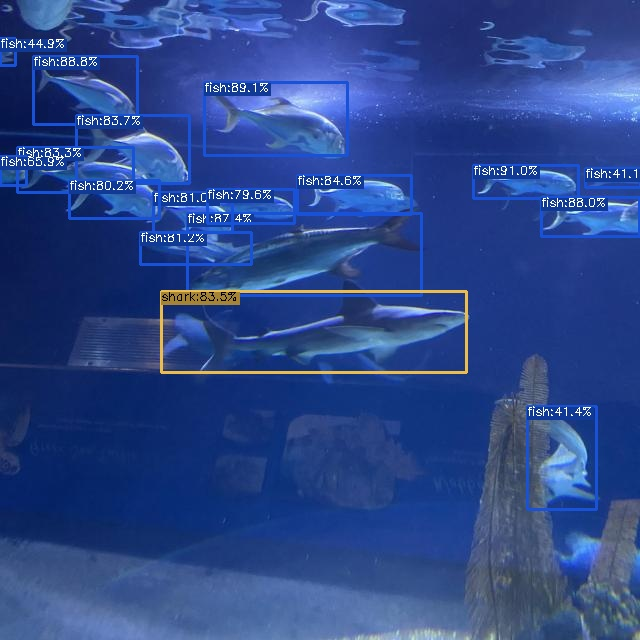

In [40]:
# Calling the postprocessing function.
run_postprocess(
    image_path=test_image, 
    input_shape=input_shape,
    output_path=output_path,
    output_from_model=output_from_model,
    class_names=class_names,
    output_source='sagemaker'
)